# Semantic Search with miniLM for Harry Potter Passages

This notebook demonstrates semantic search using the miniLM model from HuggingFace on the Harry Potter text chunks.

Steps covered:
1. Load the preprocessed text chunks
2. Initialize the semantic searcher with miniLM
3. Evaluate the vector space quality
4. Perform example searches
5. Analyze the results
6. Compare with TF-IDF results

## Setup

First, let's import the necessary libraries and modules.

In [1]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Add the src directory to the path so we can import our modules
sys.path.append('../src')

from preprocessing import load_chunks
from semantic_search import SemanticSearcher, run_example_searches

[nltk_data] Downloading package punkt_tab to /home/user/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. Load the Preprocessed Text Chunks

We'll load the text chunks that were created in the first notebook.

In [2]:
# Load the chunks
chunks = load_chunks('../data/text_chunks.json')

print(f"Loaded {len(chunks)} chunks")
print(f"First chunk: {chunks[0][:150]}...")

Loaded 972 chunks
First chunk: Harry Potter and the Sorcerer's Stone Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you...


## 2. Initialize the Semantic Searcher with miniLM

Now we'll initialize the semantic searcher with the miniLM model. We'll use the `all-MiniLM-L6-v2` model from the sentence-transformers library.

In [3]:
# Initialize the semantic searcher
model_name = "sentence-transformers/all-MiniLM-L6-v2"
searcher = SemanticSearcher(chunks, model_name=model_name)

Loading model: sentence-transformers/all-MiniLM-L6-v2


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Generating embeddings for all chunks...
Embedding dimension: 384
Added 972 embeddings to Faiss index


Let's examine why we chose this particular model.

In [4]:
# Get model rationale
model_rationale = searcher._get_model_rationale()

print(f"Model choice: {model_name}")
print("\nRationale:")
for key, value in model_rationale.items():
    print(f"- {key}: {value}")

# Save model info
searcher.save_model_info('../results')

Model choice: sentence-transformers/all-MiniLM-L6-v2

Rationale:
- performance: Good balance between performance and speed with 6 layers
- training_data: Trained on diverse datasets, making it robust for general text
- embedding_size: 384-dimensional embeddings (compact but expressive)
- benchmarks: Strong performance on the MTEB benchmark
- optimization: Specifically optimized for semantic similarity tasks
Model information saved to ../results/semantic_model_info.json


'../results/semantic_model_info.json'

## 3. Evaluate the Vector Space Quality

Now we'll evaluate the quality of the vector space by checking uniformity and alignment.

In [5]:
# Evaluate vector space
metrics = searcher.evaluate_vector_space('../results')

print("Vector Space Evaluation Metrics:")
for key, value in metrics.items():
    print(f"- {key}: {value:.4f}")

Vector Space Evaluation Metrics:
- mean_distance: 1.1227
- std_distance: 0.1007
- mean_consecutive_distance: 0.9520
- mean_random_distance: 1.1215
- alignment_ratio: 0.8488


Let's load and display the plots that were generated during the evaluation.

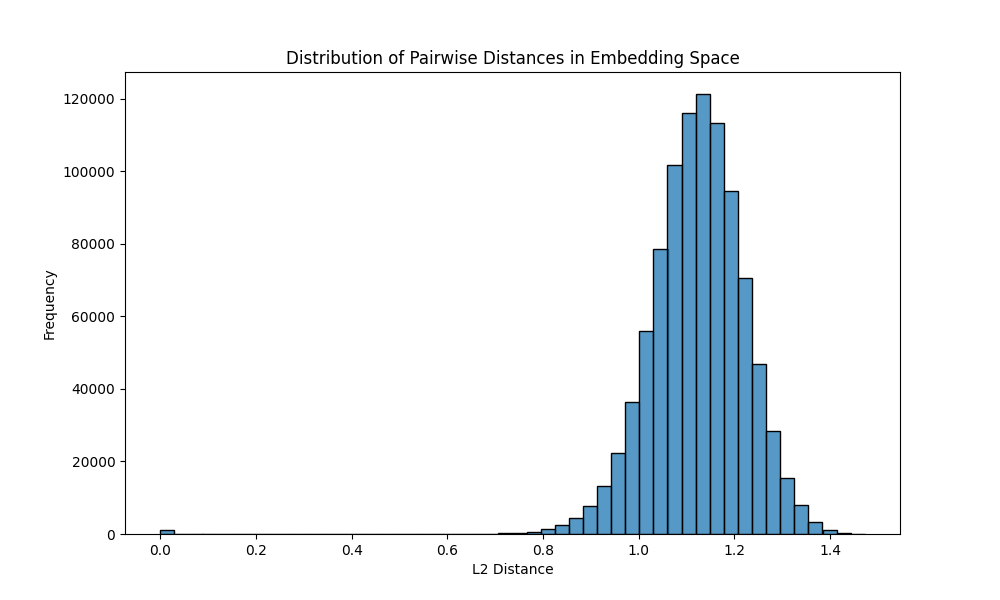

In [6]:
# Display the distance distribution plot
from IPython.display import Image
Image(filename='../results/embedding_distance_distribution.png')

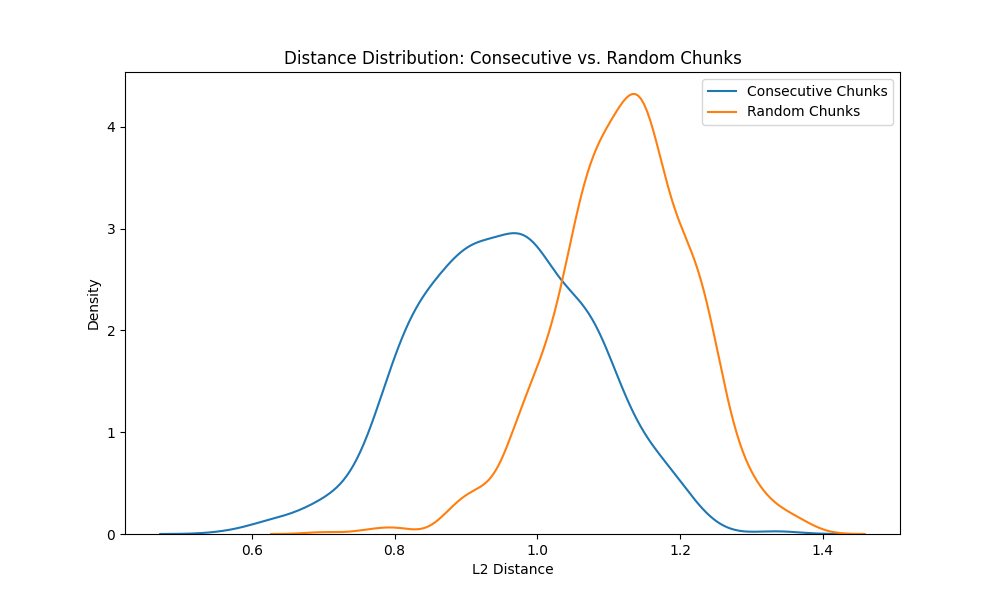

In [7]:
# Display the consecutive vs random distances plot
Image(filename='../results/consecutive_vs_random_distances.png')

## 4. Perform Example Searches

Now we'll perform some example searches to demonstrate the semantic search capabilities.

In [8]:
# Define example queries (same as in the TF-IDF notebook for comparison)
example_queries = [
    "Harry's first day at Hogwarts",
    "Quidditch match rules",
    "Voldemort and the Philosopher's Stone"
]

# Create results directory if it doesn't exist
os.makedirs('../results', exist_ok=True)

# Run example searches
results = run_example_searches(searcher, example_queries, '../results/semantic_results.json')


Query: Harry's first day at Hogwarts
Result 1 (Score: 0.6215):
It was the first really fine day they'd had in months. The sky was a clear, forget-me-not blue, and there was a feeling in the air of summer coming. H...
Result 2 (Score: 0.5947):
Everyone starts at the beginning at Hogwarts, you'll be just fine. just be yerself. I know it's hard. Yeh've been singled out, an' that's always hard....
Result 3 (Score: 0.5845):
Harry had the best morning he'd had in a long time. He was careful to walk a little way apart from the Dursleys so that Dudley and Piers, who were sta...
Result 4 (Score: 0.5675):
It started to rain. Great drops beat on the roof of the car. Dud ley sniveled. "It's Monday," he told his mother. "The Great Humberto's on tonight. I ...
Result 5 (Score: 0.5514):
Lots of people had come from Muggle families and, like him, hadn't had any idea that they were witches and wizards. There was so much to learn that ev...

Query: Quidditch match rules
Result 1 (Score: 0.6488):
You've

## 5. Analyze the Results

Let's analyze the results of our example searches.

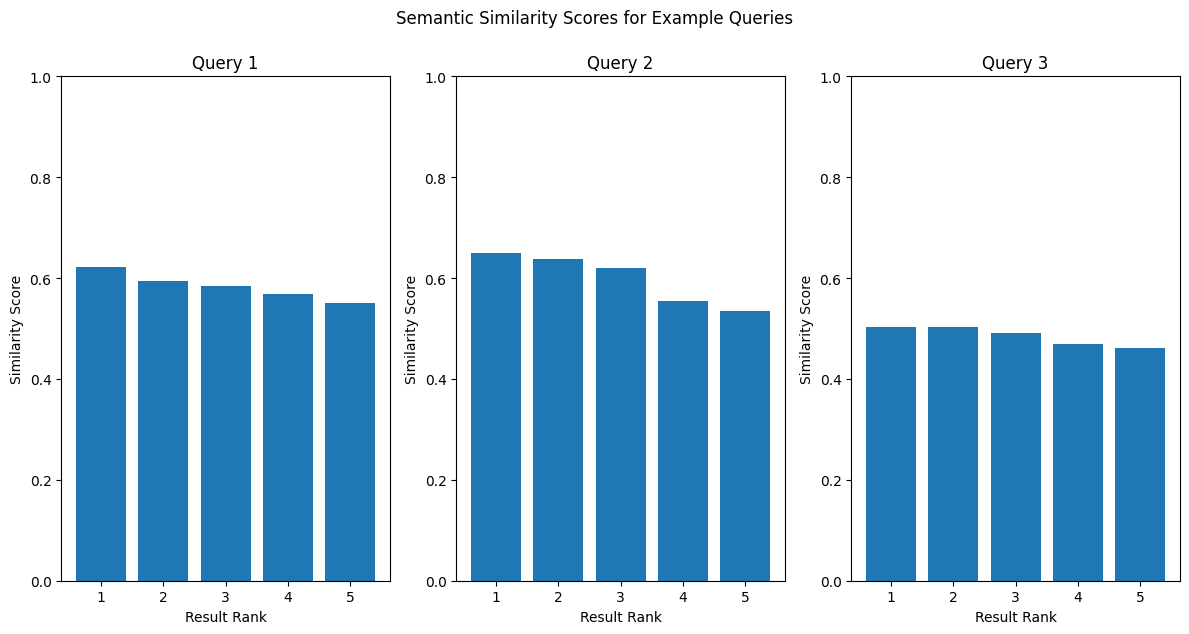

In [9]:
# Visualize the scores for each query
plt.figure(figsize=(12, 6))

for i, query in enumerate(example_queries):
    scores = [result['score'] for result in results[query]]
    plt.subplot(1, 3, i+1)
    plt.bar(range(1, len(scores)+1), scores)
    plt.title(f"Query {i+1}")
    plt.xlabel('Result Rank')
    plt.ylabel('Similarity Score')
    plt.ylim(0, 1)
    
plt.tight_layout()
plt.suptitle('Semantic Similarity Scores for Example Queries', y=1.05)
plt.savefig('../results/semantic_scores.png')
plt.show()

## 6. Compare with TF-IDF Results

Now let's compare the semantic search results with the TF-IDF results from the previous notebook.

In [10]:
# Load TF-IDF results
with open('../results/tfidf_results.json', 'r', encoding='utf-8') as f:
    tfidf_results = json.load(f)

# Compare results for each query
for query in example_queries:
    print(f"\nQuery: {query}")
    
    # Get chunk IDs from both methods
    tfidf_chunk_ids = [result['chunk_id'] for result in tfidf_results[query]]
    semantic_chunk_ids = [result['chunk_id'] for result in results[query]]
    
    # Calculate overlap
    common_chunks = set(tfidf_chunk_ids).intersection(set(semantic_chunk_ids))
    overlap_percentage = len(common_chunks) / len(tfidf_chunk_ids) * 100
    
    print(f"Overlap: {len(common_chunks)} out of {len(tfidf_chunk_ids)} chunks ({overlap_percentage:.2f}%)")
    print(f"Common chunk IDs: {common_chunks}")
    print(f"TF-IDF unique: {set(tfidf_chunk_ids) - set(semantic_chunk_ids)}")
    print(f"Semantic unique: {set(semantic_chunk_ids) - set(tfidf_chunk_ids)}")


Query: Harry's first day at Hogwarts
Overlap: 1 out of 5 chunks (20.00%)
Common chunk IDs: {275}
TF-IDF unique: {514, 402, 279, 175}
Semantic unique: {721, 426, 140, 87}

Query: Quidditch match rules
Overlap: 1 out of 5 chunks (20.00%)
Common chunk IDs: {571}
TF-IDF unique: {681, 579, 611, 572}
Semantic unique: {535, 684, 527, 399}

Query: Voldemort and the Philosopher's Stone
Overlap: 1 out of 5 chunks (20.00%)
Common chunk IDs: {692}
TF-IDF unique: {850, 36, 821, 820}
Semantic unique: {849, 908, 842, 932}


Let's visualize the overlap between TF-IDF and semantic search results.

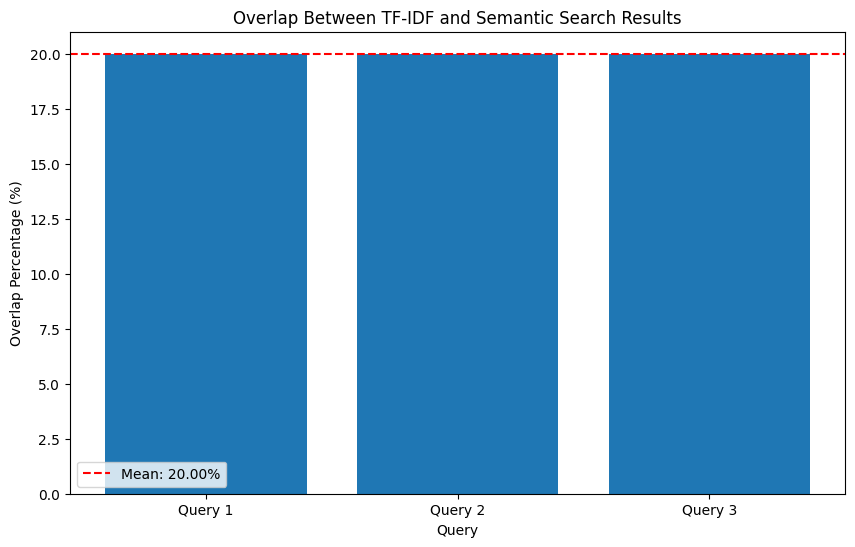

In [11]:
# Calculate overlap percentages
overlaps = []
for query in example_queries:
    tfidf_chunk_ids = [result['chunk_id'] for result in tfidf_results[query]]
    semantic_chunk_ids = [result['chunk_id'] for result in results[query]]
    common_chunks = set(tfidf_chunk_ids).intersection(set(semantic_chunk_ids))
    overlap_percentage = len(common_chunks) / len(tfidf_chunk_ids) * 100
    overlaps.append(overlap_percentage)

# Plot overlap percentages
plt.figure(figsize=(10, 6))
plt.bar(range(len(overlaps)), overlaps)
plt.axhline(y=np.mean(overlaps), color='r', linestyle='--', label=f'Mean: {np.mean(overlaps):.2f}%')
plt.xlabel('Query')
plt.ylabel('Overlap Percentage (%)')
plt.title('Overlap Between TF-IDF and Semantic Search Results')
plt.xticks(range(len(overlaps)), [f'Query {i+1}' for i in range(len(overlaps))])
plt.legend()
plt.savefig('../results/overlap_percentage.png')
plt.show()

## 7. Demonstrate Semantic Understanding

Let's demonstrate how semantic search can overcome the lexical gap problem that we identified with TF-IDF.

In [12]:
# Define two semantically similar queries with different wording (same as in TF-IDF notebook)
query1 = "Harry's scar hurts"
query2 = "Pain in Harry's forehead"

# Search with both queries
results1 = searcher.search(query1)
results2 = searcher.search(query2)

# Get the chunk IDs for both results
chunk_ids1 = [result['chunk_id'] for result in results1]
chunk_ids2 = [result['chunk_id'] for result in results2]

# Calculate overlap
common_chunks = set(chunk_ids1).intersection(set(chunk_ids2))
overlap_percentage = len(common_chunks) / len(chunk_ids1) * 100

print(f"Query 1: {query1}")
print(f"Query 2: {query2}")
print(f"\nOverlap in results: {len(common_chunks)} out of {len(chunk_ids1)} chunks ({overlap_percentage:.2f}%)")
print(f"Common chunk IDs: {common_chunks}")

# Print the first result for each query
print(f"\nFirst result for Query 1:")
print(f"Chunk ID: {results1[0]['chunk_id']}")
print(f"Score: {results1[0]['score']:.4f}")
print(f"Text: {results1[0]['text'][:200]}...")

print(f"\nFirst result for Query 2:")
print(f"Chunk ID: {results2[0]['chunk_id']}")
print(f"Score: {results2[0]['score']:.4f}")
print(f"Text: {results2[0]['text'][:200]}...")

Query 1: Harry's scar hurts
Query 2: Pain in Harry's forehead

Overlap in results: 0 out of 5 chunks (0.00%)
Common chunk IDs: set()

First result for Query 1:
Chunk ID: 50
Score: 0.5967
Text: "Is that where -?" whispered Professor McGonagall. "Yes," said Dumbledore. "He'll have that scar forever." "Couldn't you do something about it, Dumbledore?" "Even if I could, I wouldn't. Scars can com...

First result for Query 2:
Chunk ID: 649
Score: 0.5687
Text: One book had a dark stain on it that looked horribly like blood. The hairs on the back of Harry's neck prickled. Maybe he was imagining it, maybe not, but he thought a faint whispering was coming from...


## Summary

In this notebook, we've:
1. Loaded the preprocessed text chunks
2. Initialized the semantic searcher with the miniLM model
3. Evaluated the vector space quality
4. Performed example searches
5. Analyzed the results
6. Compared with TF-IDF results
7. Demonstrated semantic understanding

We've seen that semantic search using miniLM can overcome some of the limitations of TF-IDF, particularly the lexical gap problem. The semantic search results are based on the meaning of the text rather than just the presence of specific terms, allowing it to find relevant passages even when the query uses different wording.

In the next notebook, we'll evaluate the TF-IDF results against the semantic search results as ground truth.